# Data & ETF Universe — AI Exposure Factor Suite

**Notebook 01** of the AI Exposure Factor Suite analysis series.

This notebook documents the **raw inputs** behind the two daily market-implied AI return factors built by this project:

1. **AI Theme Factor** ($F^{AI\ Theme}$) — a lagged-AUM-weighted basket of AI-theme ETF excess returns.
2. **AI Infrastructure Factor** ($F^{AI\ Infra}$) — the excess return of a dedicated semiconductor ETF (SOXX).

Audience: a quant researcher reviewing the factor methodology. Every step below states *what* is done, *why*, and the relevant caveats from the methodology spec (`part_1_ai_exposure_factor_suite_etf_factors.md`).

> **Offline note:** this notebook reads only the already-fetched files under `data/` and `config/`. It makes no network calls (no yfinance, FRED, or Ken French downloads).

## 0. Setup

One import/setup cell. All paths are built from `PROJECT_ROOT` (the repository root, one level up from `notebooks/`), so the notebook runs identically regardless of the working directory it is launched from — matching how the `src/` pipeline resolves paths.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# pandas.read_feather() currently emits a noisy pyarrow-related FutureWarning
# that is irrelevant to the analysis; suppress it to keep outputs readable.
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path("..").resolve()
DATA = PROJECT_ROOT / "data"
CONFIG = PROJECT_ROOT / "config"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Consistent colors per bucket, reused across all plots.
BUCKET_COLORS = {"theme": "#1f77b4", "infra": "#d62728", "excluded": "#7f7f7f"}

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

PROJECT_ROOT = <repo-root>
pandas 2.3.3 | numpy 2.5.1


## 1. Project goal and the two factors

The objective of the suite is to construct **clean, point-in-time, market-implied AI factor return series** that can later be used to estimate firm-level AI exposure betas (for Russell 1000 / S&P 500 constituents) via time-series regressions.

### 1.1 AI Theme Factor

A lagged-AUM-weighted basket of **excess returns** of AI-theme ETFs:

$$F^{AI\ Theme}_t = \sum_{e \,\in\, \text{Theme}_t} w_{e,\,t-1} \cdot \left( R_{e,t} - Rf_t \right)$$

where $R_{e,t}$ is the daily simple return of theme ETF $e$ (from adjusted prices), $Rf_t$ is the **daily** risk-free rate, and the weights

$$w_{e,\,t-1} = \frac{AUM_{e,\,t-1}}{\sum_{j \in \text{Theme}_t} AUM_{j,\,t-1}}$$

are **lagged by one day** so the factor is tradable / free of look-ahead. An ETF enters the basket only once real return data exists for it (point-in-time inclusion — no back-filled pre-inception history).

### 1.2 AI Infrastructure Factor

The excess return of a single dedicated semiconductor ETF:

$$F^{AI\ Infra}_t = R_{\text{SemiETF},\,t} - Rf_t$$

The chosen proxy is **SOXX** (iShares Semiconductor ETF; inception 2001, 30 largest US semiconductor companies, market-cap weighted), with **SMH** documented as the robustness alternative (see `config/semicond_etf_choice.txt`).

### 1.3 Why keep theme and infrastructure separate?

Per the spec, the AI trade contains **two economically distinct public-market channels**:

- firms viewed as beneficiaries of AI *adoption* — software, data, automation, generative AI (→ theme);
- firms tied to the semiconductor / accelerator / data-center / hardware *supply chain* (→ infrastructure).

Keeping them separate yields cleaner beta interpretation later: a cloud-software firm may load on theme but not infra; a chipmaker the reverse; a large platform may load on both. Two honest caveats carried through from the spec:

- broad AI-theme ETFs may still *hold* semiconductor names, so the theme factor is **not** semiconductor-free by construction;
- the infra factor is **not** AI-only — it also captures the broader semiconductor cycle.

Deliberately excluded from both: QQQ and other broad tech proxies (they would dilute the AI signal with generic mega-cap growth exposure).

## 2. ETF eligibility universe

The classification of every candidate ETF lives in `config/etf_classifications.csv`. Each row records the bucket assignment (`theme` / `infra` / `excluded`), inception and first-return dates, and a written rationale with source.

**Eligibility rule (per spec §4):** an ETF can enter the AI universe at date $t$ if, as of date $t$, its fund name, index name, stated investment objective, or methodology **explicitly identifies AI** (artificial intelligence, machine learning, generative AI, robotics/automation *with explicit AI emphasis*) as a central theme.

**Exclusions:**
- **Leveraged / inverse products** (e.g. SOXL, 3× semiconductor bull) — never eligible;
- **Broad technology funds** (QQQ, XLK, IYW) — too generic, would dilute the AI signal;
- **AI-not-central mandates** (ARKW);
- **AIEQ** — uses AI to *select* stocks rather than *holding* AI companies; it is not AI exposure.

In [2]:
etf_cls = pd.read_csv(CONFIG / "etf_classifications.csv", parse_dates=[
    "inclusion_start_date", "inception_date", "first_return_date"])

# Full table (the columns that matter for the methodology review).
display_cols = ["ticker", "fund_name", "issuer", "bucket",
                "inception_date", "first_return_date", "classification_rationale"]
etf_cls[display_cols].sort_values(["bucket", "inception_date"]).reset_index(drop=True)

,ticker,fund_name,issuer,bucket,inception_date,first_return_date,classification_rationale
0,XLK,Technology Select Sector SPDR Fund,State Street,excluded,1998-12-22,1998-12-23,Broad technology sector ETF. Excluded per spec.
1,QQQ,Invesco QQQ Trust,Invesco,excluded,1999-03-10,1999-03-11,Nasdaq-100 ETF. Excluded per spec - too broad.
2,IYW,iShares U.S. Technology ETF,iShares,excluded,2000-06-12,2000-06-13,Broad technology sector ETF. Excluded per spec.
3,SOXL,Semiconductor Bull 3x ETF,DIRK,excluded,2010-03-11,2010-03-12,3x leveraged semiconductor ETF. Excluded per s...
4,ARKW,ARK Next Generation Internet ETF,ARK,excluded,2014-09-03,2014-09-04,Broad innovation/tech ETF. AI not central to m...
5,AIEQ,AI Powered Equity ETF,Equbot,excluded,2017-10-18,2017-10-19,AI-selected portfolio not AI exposure. Uses AI...
6,SOXX,iShares Semiconductor ETF,iShares,infra,2001-07-10,2001-07-11,Dedicated semiconductor ETF. 30 largest US sem...
7,SMH,Vaneck Semiconductor ETF,VanEck,infra,2011-12-20,2011-12-21,Dedicated semiconductor ETF. 25 largest semico...
8,ROBO,ROBO Global Robotics and Automation Index ETF,ROBO Global,theme,2013-10-22,2013-10-23,"Robotics and automation theme. Older product, ..."
9,ARKQ,ARK Autonomous Technology & Robotics ETF,ARK,theme,2014-09-03,2014-09-04,Autonomous technology and robotics. AI-adjacent.


In [3]:
bucket_counts = etf_cls["bucket"].value_counts()
print("ETF counts by bucket:")
print(bucket_counts.to_string())
print(f"\nTotal candidate ETFs classified: {len(etf_cls)}")
print(f"Theme ETFs: {', '.join(sorted(etf_cls.loc[etf_cls.bucket == 'theme', 'ticker']))}")
print(f"Infra ETFs: {', '.join(sorted(etf_cls.loc[etf_cls.bucket == 'infra', 'ticker']))}")

ETF counts by bucket:
bucket
theme       7
excluded    6
infra       2

Total candidate ETFs classified: 15
Theme ETFs: AIQ, ARKQ, BOTZ, IRBO, ROBO, THNQ, WTAI
Infra ETFs: SMH, SOXX


### 2.1 Timeline of ETF inceptions

The chart below shows each ETF's inception date, colored by bucket. Two things to note:

- the AI-theme universe is **young** — the first theme ETF (ROBO) only starts in October 2013, so the theme factor cannot exist before then;
- the infrastructure proxy (SOXX) reaches back to 2001, which is why the infra factor has a much longer history.

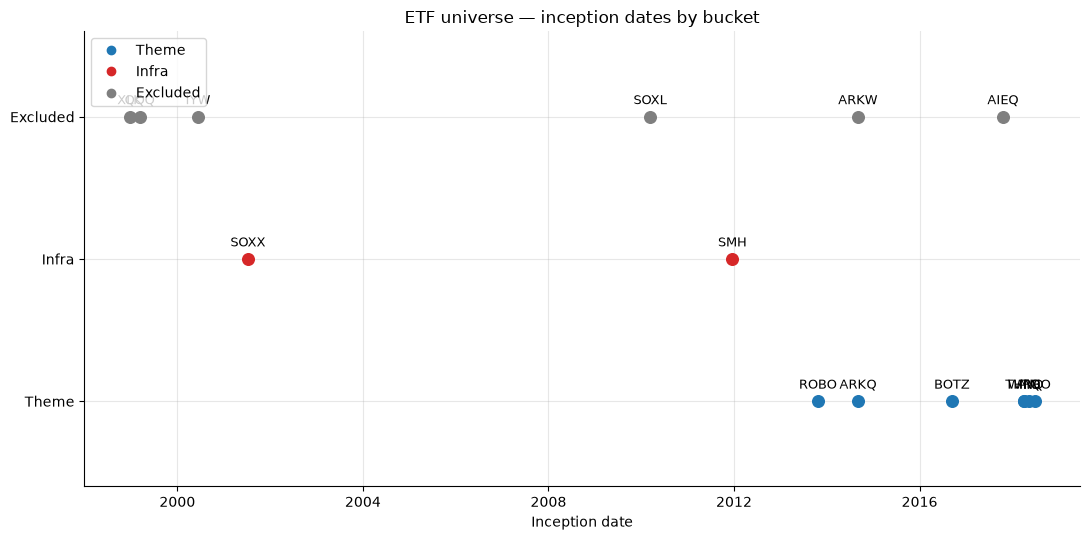

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))
bucket_order = ["theme", "infra", "excluded"]
y_pos = {b: i for i, b in enumerate(bucket_order)}

for _, row in etf_cls.iterrows():
    y = y_pos[row["bucket"]]
    ax.scatter(row["inception_date"], y, color=BUCKET_COLORS[row["bucket"]],
               s=70, zorder=3)
    ax.annotate(row["ticker"], (row["inception_date"], y),
                textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9)

ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels([b.capitalize() for b in bucket_order])
ax.set_ylim(-0.6, len(bucket_order) - 0.4)
ax.set_xlabel("Inception date")
ax.set_title("ETF universe — inception dates by bucket")
handles = [plt.Line2D([], [], marker="o", ls="", color=BUCKET_COLORS[b], label=b.capitalize())
           for b in bucket_order]
ax.legend(handles=handles, loc="upper left")
plt.tight_layout()
plt.show()

## 3. Data sources

All inputs are fetched once by the pipeline (`src/`) and stored locally as feather files; this notebook reads those files directly.

| Data | Source | File | Frequency / scope |
|---|---|---|---|
| ETF OHLCV + daily returns | Yahoo Finance (adjusted prices) | `data/raw/etf_returns/etf_returns.feather` | Daily, per ticker since inception |
| ETF AUM | Yahoo Finance fund profile | `data/raw/etf_aum/etf_aum_current.feather` | **Current snapshot only** |
| Risk-free rate (3-month T-bill, TB3MS) | FRED | `data/reference/rf_rate_TB3MS.feather` | Monthly, annualized decimal |
| Fama-French 5 factors + momentum | Ken French data library | `data/reference/ff_factors_daily.feather` | Daily, **decimal** units |
| Fama-French factors (legacy) | Ken French data library | `data/reference/ff_factors.feather` | Monthly, **percent** units |
| NYSE trading calendar | exchange calendar | `data/reference/trading_calendar.feather` | Daily calendar grid |

Units matter and differ across files — they are checked explicitly in Section 6.

## 4. ETF returns data

`data/raw/etf_returns/etf_returns.feather` holds daily OHLCV plus a `return` column: the **daily simple return computed from adjusted prices** (dividend- and split-adjusted), which is what the factor formulas consume. The `date` column is timezone-aware (America/New_York); we normalize it to tz-naive timestamps for joining against the reference data.

Note that only the **9 active ETFs** (7 theme + 2 infra) were fetched — the excluded ETFs are not part of any factor, so their price history is not stored.

In [5]:
rets = pd.read_feather(DATA / "raw/etf_returns/etf_returns.feather")
# Normalize tz-aware dates (America/New_York) to tz-naive for joining.
rets["date"] = pd.to_datetime(rets["date"]).dt.tz_localize(None)
rets = rets.sort_values(["ticker", "date"]).reset_index(drop=True)

print(f"Rows: {len(rets):,} | tickers: {rets['ticker'].nunique()} | "
      f"{rets['date'].min().date()} → {rets['date'].max().date()}")
rets.head(3)

Rows: 23,569 | tickers: 9 | 2010-01-04 → 2026-06-18


,date,ticker,open,high,low,close,volume,return,data_quality_flag
0,2018-05-16,AIQ,14.612365,14.631796,14.583218,14.608479,6200,NaN,ok
1,2018-05-17,AIQ,14.592934,14.748384,14.583218,14.670659,57100,0.004256,ok
2,2018-05-18,AIQ,14.602647,14.617221,14.524922,14.557956,47500,-0.007682,ok


### 4.1 Coverage per ticker

Each ticker's first row has a NaN return by construction (no previous close), which is why `n_obs` (all rows) exceeds `n_returns` (valid returns) by exactly one everywhere.

In [6]:
coverage = (rets.groupby("ticker")
            .agg(first_date=("date", "min"), last_date=("date", "max"),
                 n_obs=("date", "size"), n_returns=("return", "count"))
            .sort_values("first_date"))
coverage["first_date"] = coverage["first_date"].dt.date
coverage["last_date"] = coverage["last_date"].dt.date
coverage

,first_date,last_date,n_obs,n_returns
ticker,,,,
SMH,2010-01-04,2026-06-18,4140,4139
SOXX,2010-01-04,2026-06-18,4140,4139
ROBO,2013-10-22,2026-06-18,3183,3182
ARKQ,2014-09-30,2026-06-18,2947,2946
BOTZ,2016-09-13,2026-06-18,2455,2454
AIQ,2018-05-16,2026-06-18,2034,2033
IRBO,2018-06-26,2026-06-18,2005,2004
THNQ,2020-05-18,2026-06-18,1530,1529
WTAI,2021-12-09,2026-06-18,1135,1134


### 4.2 Normalized cumulative performance

Cumulative growth of \$1 per ETF, rebased to each fund's first valid return, on a log scale. The long dominance of the two semiconductor funds (SMH, SOXX) — especially post-2022 — is the visual motivation for keeping infrastructure in its **own** factor rather than letting it swamp the theme basket.

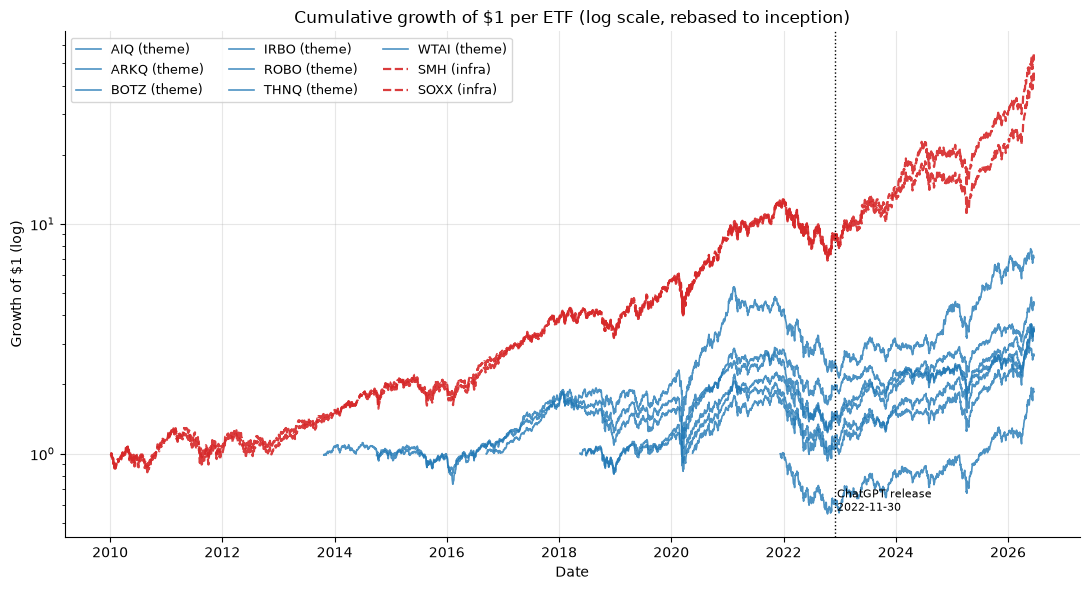

In [7]:
ret_piv = rets.pivot(index="date", columns="ticker", values="return")
theme_etfs = sorted(etf_cls.loc[etf_cls.bucket == "theme", "ticker"])
infra_etfs = sorted(etf_cls.loc[etf_cls.bucket == "infra", "ticker"])

fig, ax = plt.subplots(figsize=(11, 6))
for t in theme_etfs:
    s = ret_piv[t].dropna()
    ax.plot(s.index, (1 + s).cumprod(), color=BUCKET_COLORS["theme"],
            alpha=0.8, lw=1.2, label=f"{t} (theme)")
for t in infra_etfs:
    s = ret_piv[t].dropna()
    ax.plot(s.index, (1 + s).cumprod(), color=BUCKET_COLORS["infra"],
            alpha=0.9, lw=1.6, ls="--", label=f"{t} (infra)")

ax.set_yscale("log")
ax.set_title("Cumulative growth of $1 per ETF (log scale, rebased to inception)")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1 (log)")
ax.axvline(pd.Timestamp("2022-11-30"), color="black", ls=":", lw=1)
ax.text(pd.Timestamp("2022-12-15"), ax.get_ylim()[0] * 1.3,
        "ChatGPT release\n2022-11-30", fontsize=8)
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

### 4.3 Daily return distribution

Summary statistics of daily simple returns per ticker. The semiconductor funds show the highest daily volatility and the fattest right tail — consistent with their role as the high-beta infrastructure leg of the AI trade.

In [8]:
dist = (rets.groupby("ticker")["return"]
        .agg(n="count", mean="mean", std="std", min="min",
             q01=lambda s: s.quantile(0.01), median="median",
             q99=lambda s: s.quantile(0.99), max="max", skew="skew")
        .round(4))
dist["ann_vol_%"] = (dist["std"] * np.sqrt(252) * 100).round(1)
dist

,n,mean,std,min,q01,median,q99,max,skew,ann_vol_%
ticker,,,,,,,,,,
AIQ,2033,0.0009,0.0162,-0.0983,-0.0449,0.0016,0.0416,0.1219,-0.1588,25.7
ARKQ,2946,0.0008,0.0181,-0.1044,-0.0452,0.0014,0.0465,0.1405,-0.0514,28.7
BOTZ,2454,0.0005,0.0163,-0.1241,-0.0439,0.0009,0.0404,0.1277,-0.0965,25.9
IRBO,2004,0.0008,0.0178,-0.1022,-0.0474,0.0014,0.0441,0.1318,-0.1862,28.3
ROBO,3182,0.0005,0.0138,-0.1116,-0.0369,0.0008,0.0347,0.1023,-0.2298,21.9
SMH,4139,0.0011,0.0184,-0.1441,-0.0487,0.0015,0.0484,0.1716,-0.0472,29.2
SOXX,4139,0.0011,0.0191,-0.1523,-0.0494,0.0013,0.0505,0.1857,-0.0042,30.3
THNQ,1529,0.0010,0.0182,-0.0698,-0.0436,0.0016,0.0420,0.1278,0.0376,28.9
WTAI,1134,0.0007,0.0198,-0.0883,-0.0488,0.0015,0.0470,0.1309,0.0648,31.4


### 4.4 Data-quality checks

Minimal sanity checks before any factor construction:

1. **Missing returns** — any dates with no return where one should exist;
2. **Extreme moves** — |daily return| > 25%, which for a diversified ETF would indicate a data error rather than a real move;
3. **Pipeline quality flags** — the fetch pipeline annotates each row with a `data_quality_flag`.

In [9]:
missing = rets["return"].isna().sum()
per_ticker_na = rets.loc[rets["return"].isna()].groupby("ticker")["return"].size()
extreme = rets.loc[rets["return"].abs() > 0.25]

print(f"Total NaN returns: {missing} "
      f"(expected {rets['ticker'].nunique()} — one inception-day NaN per ticker)")
print("NaN returns per ticker:", per_ticker_na.to_dict())
print(f"Extreme moves |r| > 25%: {len(extreme)}")
print("data_quality_flag values:", rets["data_quality_flag"].value_counts().to_dict())
print(f"Largest absolute daily move: {rets['return'].abs().max():.2%} "
      f"({rets.loc[rets['return'].abs().idxmax(), 'ticker']})")

Total NaN returns: 9 (expected 9 — one inception-day NaN per ticker)
NaN returns per ticker: {'AIQ': 1, 'ARKQ': 1, 'BOTZ': 1, 'IRBO': 1, 'ROBO': 1, 'SMH': 1, 'SOXX': 1, 'THNQ': 1, 'WTAI': 1}
Extreme moves |r| > 25%: 0
data_quality_flag values: {'ok': 23569}
Largest absolute daily move: 18.57% (SOXX)


## 5. AUM snapshot

`data/raw/etf_aum/etf_aum_current.feather` holds each active ETF's assets under management — the input to the theme-basket weights $w_{e,t-1}$.

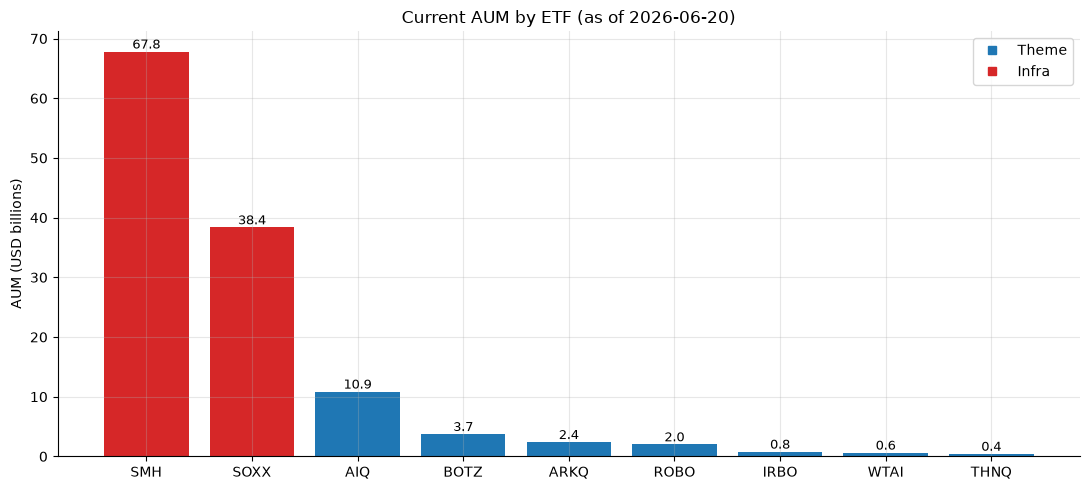

Total AUM (9 active ETFs): $127.1 bn
  theme bucket: $20.9 bn | infra bucket: $106.2 bn
Theme-basket weights implied by current AUM:
ticker    aum_bn  weight
   AIQ 10.853202   0.520
  BOTZ  3.743228   0.179
  ARKQ  2.405847   0.115
  ROBO  2.022659   0.097
  IRBO  0.788096   0.038
  WTAI  0.622808   0.030
  THNQ  0.432978   0.021


In [10]:
aum = pd.read_feather(DATA / "raw/etf_aum/etf_aum_current.feather")
aum = aum.merge(etf_cls[["ticker", "bucket"]], on="ticker", how="left")
aum["aum_bn"] = aum["aum"] / 1e9

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = aum.sort_values("aum_bn", ascending=False)
ax.bar(plot_df["ticker"], plot_df["aum_bn"],
       color=[BUCKET_COLORS[b] for b in plot_df["bucket"]])
for i, (t, v) in enumerate(zip(plot_df["ticker"], plot_df["aum_bn"])):
    ax.text(i, v, f"{v:,.1f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("AUM (USD billions)")
ax.set_title(f"Current AUM by ETF (as of {aum['as_of_date'].iloc[0]})")
handles = [plt.Line2D([], [], marker="s", ls="", color=BUCKET_COLORS[b], label=b.capitalize())
           for b in ["theme", "infra"]]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

theme_aum = aum.loc[aum.bucket == "theme", "aum_bn"].sum()
infra_aum = aum.loc[aum.bucket == "infra", "aum_bn"].sum()
print(f"Total AUM (9 active ETFs): ${aum['aum_bn'].sum():,.1f} bn")
print(f"  theme bucket: ${theme_aum:,.1f} bn | infra bucket: ${infra_aum:,.1f} bn")
print(f"Theme-basket weights implied by current AUM:")
w = (aum.loc[aum.bucket == "theme", ["ticker", "aum_bn"]]
     .assign(weight=lambda d: (d["aum_bn"] / d["aum_bn"].sum()).round(3))
     .sort_values("weight", ascending=False))
print(w.to_string(index=False))

### 5.1 Caveat: current snapshot, not point-in-time AUM

This file is a **current snapshot only** — historical point-in-time AUM is not available in the dataset. The pipeline therefore applies *today's* AUM proportions across the whole history when computing theme-basket weights. Implications:

- **No look-ahead in inclusion** (ETFs still enter only when real return data exists), but **look-ahead in relative sizing**: an ETF that is large today is large throughout its history in the backtest, even if it was small at inception.
- Weights are constant over time in relative terms, so the factor does not capture flows into/out of the AI theme.

This is a documented limitation and is on the Phase 2 roadmap (source historical AUM or shares-outstanding × NAV to rebuild point-in-time weights).

## 6. Reference data

Three reference series feed the factor construction: the risk-free rate, the Fama-French factors (for later alpha/beta analysis), and the NYSE trading calendar.

### 6.1 Risk-free rate (FRED TB3MS)

`rf_rate_TB3MS.feather` is the **monthly** 3-month T-bill rate, stored as an **annualized decimal** (0.036 = 3.6% p.a.). The pipeline forward-fills it to daily and converts to a daily rate:

$$Rf_t^{daily} = \frac{Rf^{annual}}{252}$$

> **Methodology note (fixed bug):** an earlier pipeline version subtracted the *annualized* rate from *daily* returns, producing a mean daily "excess" return of about −1.79%/day — mechanically wrong by a factor of ~252. Dividing by 252 fixed it. Because the conversion is simple, it is worth restating wherever the excess-return definition appears.

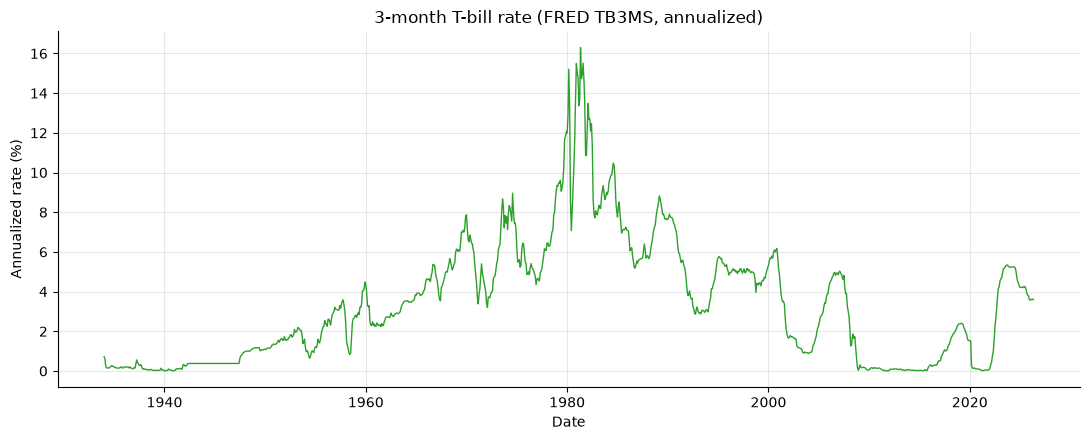

Coverage: 1934-01-01 → 2026-05-01 (1,109 monthly obs)
Latest annualized rate: 0.0360 = 3.60% p.a. → daily: 0.000143 (0.0143%)
Mean annualized rate since 2010: 1.44%


In [11]:
rf = pd.read_feather(DATA / "reference/rf_rate_TB3MS.feather")
rf["date"] = pd.to_datetime(rf["date"])

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(rf["date"], rf["rf_rate"] * 100, color="#2ca02c", lw=1)
ax.set_title("3-month T-bill rate (FRED TB3MS, annualized)")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized rate (%)")
plt.tight_layout()
plt.show()

latest = rf.iloc[-1]
print(f"Coverage: {rf['date'].min().date()} → {rf['date'].max().date()} ({len(rf):,} monthly obs)")
print(f"Latest annualized rate: {latest['rf_rate']:.4f} = {latest['rf_rate']:.2%} p.a. "
      f"→ daily: {latest['rf_rate'] / 252:.6f} ({latest['rf_rate'] / 252:.4%})")
print(f"Mean annualized rate since 2010: {rf.loc[rf['date'] >= '2010', 'rf_rate'].mean():.2%}")

### 6.2 Fama-French factors

Two files, **different units and frequency** — do not mix them up:

- `ff_factors_daily.feather` — **daily, decimal** units (0.0035 = 0.35%). The 5-factor columns (`mkt_rf, smb, hml, rmw, cma`) plus `rf` currently end **2026-05-29** (Ken French library publication lag); `umd` can run longer — the cell below prints the actual last-valid date of each.
- `ff_factors.feather` — **monthly, percent** units (legacy file, kept for reference only).

The daily file is the one used for regressions against the AI factors.

In [12]:
ffd = pd.read_feather(DATA / "reference/ff_factors_daily.feather")
ffd["date"] = pd.to_datetime(ffd["date"])
ffm = pd.read_feather(DATA / "reference/ff_factors.feather")

last_valid_5f = ffd.dropna(subset=["mkt_rf"])["date"].max()
last_valid_umd = ffd.dropna(subset=["umd"])["date"].max()
print(f"Daily file: {ffd['date'].min().date()} → {ffd['date'].max().date()}, "
      f"5-factor cols valid through {last_valid_5f.date()}, umd through {last_valid_umd.date()}")
print(f"Monthly legacy file: {pd.to_datetime(ffm['date']).min().date()} → "
      f"{pd.to_datetime(ffm['date']).max().date()}")
print("\nUnit check — recent daily rows (decimal):")
ffd.tail(3)

Daily file: 1926-11-03 → 2026-05-29, 5-factor cols valid through 2026-05-29, umd through 2026-05-29
Monthly legacy file: 1927-01-01 → 2026-05-01

Unit check — recent daily rows (decimal):


,date,mkt_rf,smb,hml,rmw,cma,rf,umd
26149,2026-05-27,0.0002,0.0037,-0.0035,0.0007,-0.0018,0.0002,-0.0027
26150,2026-05-28,0.0067,-0.0016,-0.0059,-0.0108,0.0005,0.0002,-0.0091
26151,2026-05-29,0.0019,-0.0103,-0.0026,-0.0066,0.0015,0.0002,-0.0168


### 6.3 Trading calendar

`trading_calendar.feather` provides the NYSE day grid (`is_trading_day`, `is_early_close`) used to align returns, forward-fill the risk-free rate, and define the factor's daily index.

In [13]:
cal = pd.read_feather(DATA / "reference/trading_calendar.feather")
cal["date"] = pd.to_datetime(cal["date"])

n_days = len(cal)
n_td = int(cal["is_trading_day"].sum())
n_ec = int(cal["is_early_close"].sum())
print(f"Calendar grid: {cal['date'].min().date()} → {cal['date'].max().date()} "
      f"({n_days:,} calendar days)")
print(f"Trading days: {n_td:,} ({n_td / n_days:.1%} of grid) | early closes: {n_ec:,}")
recent = cal.loc[cal["date"] >= "2026-01-01"]
print(f"Trading days from 2026-01-01 to grid end: {int(recent['is_trading_day'].sum())} "
      f"(grid extends past today, so this includes scheduled future days)")

Calendar grid: 1900-01-01 → 2027-06-20 (46,557 calendar days)
Trading days: 32,007 (68.7% of grid) | early closes: 0
Trading days from 2026-01-01 to grid end: 366 (grid extends past today, so this includes scheduled future days)


## 7. Key takeaways

- **Two factors, two channels.** $F^{AI\ Theme}_t = \sum_e w_{e,t-1}(R_{e,t} - Rf_t)$ over 7 AI-theme ETFs, and $F^{AI\ Infra}_t = R_{SOXX,t} - Rf_t$ from a single semiconductor proxy (SOXX; SMH as robustness alternative). They are kept separate because AI-adoption beneficiaries and the semiconductor supply chain are economically distinct exposures.
- **Young theme universe.** The first theme ETF (ROBO) incepted 2013-10-22, so the theme factor starts 2013-10-23; the infra factor reaches back to 2010 in the built series (SOXX itself trades since 2001). Exclusions are deliberate: leveraged/inverse (SOXL), broad tech (QQQ, XLK, IYW, ARKW), and AI-as-stock-picker (AIEQ).
- **Clean return data.** 23,569 rows across the 9 active ETFs, all flagged `ok`; the only NaN returns are the mechanical inception-day ones, and no ETF shows a |daily move| > 25%.
- **AUM is a current snapshot.** Theme weights use today's AUM across history — a documented limitation (Phase 2: point-in-time AUM). Inclusion itself remains point-in-time via actual return availability.
- **Units are the main data hazard.** The risk-free rate is *annualized* (converted to daily via /252 — the fix for the bug that once subtracted the annual rate from daily returns), FF daily factors are *decimal*, the legacy FF monthly file is *percent*.
- **Next notebook:** construction and validation of the two factor series themselves (weights, excess returns, summary statistics, and correlation with the FF factors).